# Seaborn

In [1]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


(150, 5)
2
750
Index(['sepal.length', 'sepal.width', 'petal.length', 'petal.width',
       'variety'],
      dtype='object')
sepal.length    float64
sepal.width     float64
petal.length    float64
petal.width     float64
variety          object
dtype: object
       sepal.length  sepal.width  petal.length  petal.width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


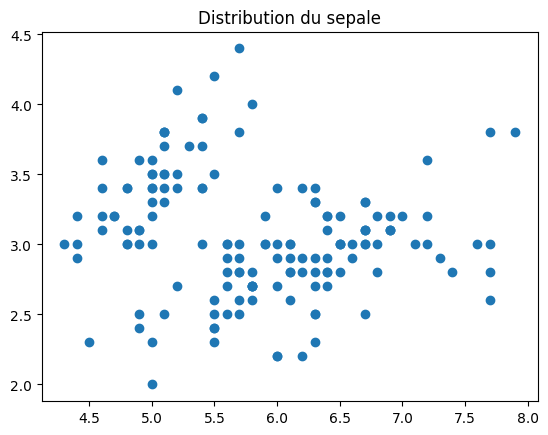

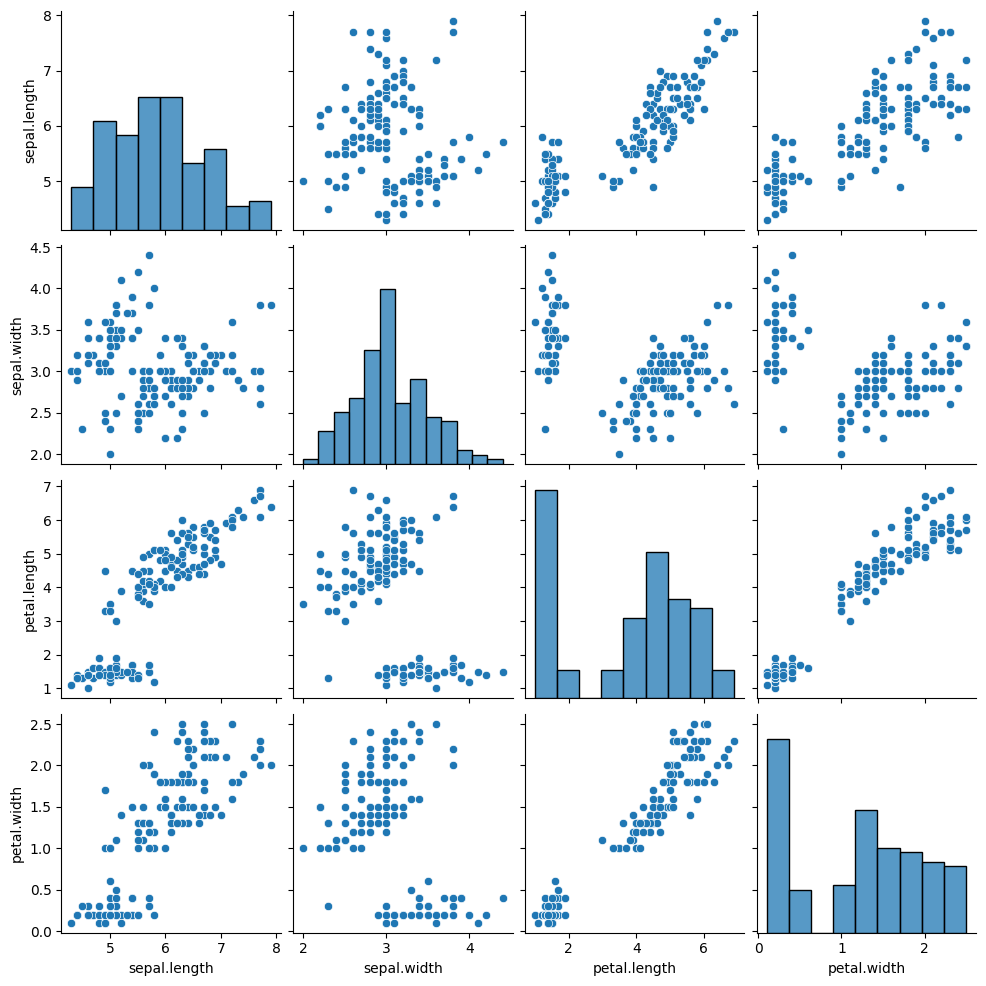

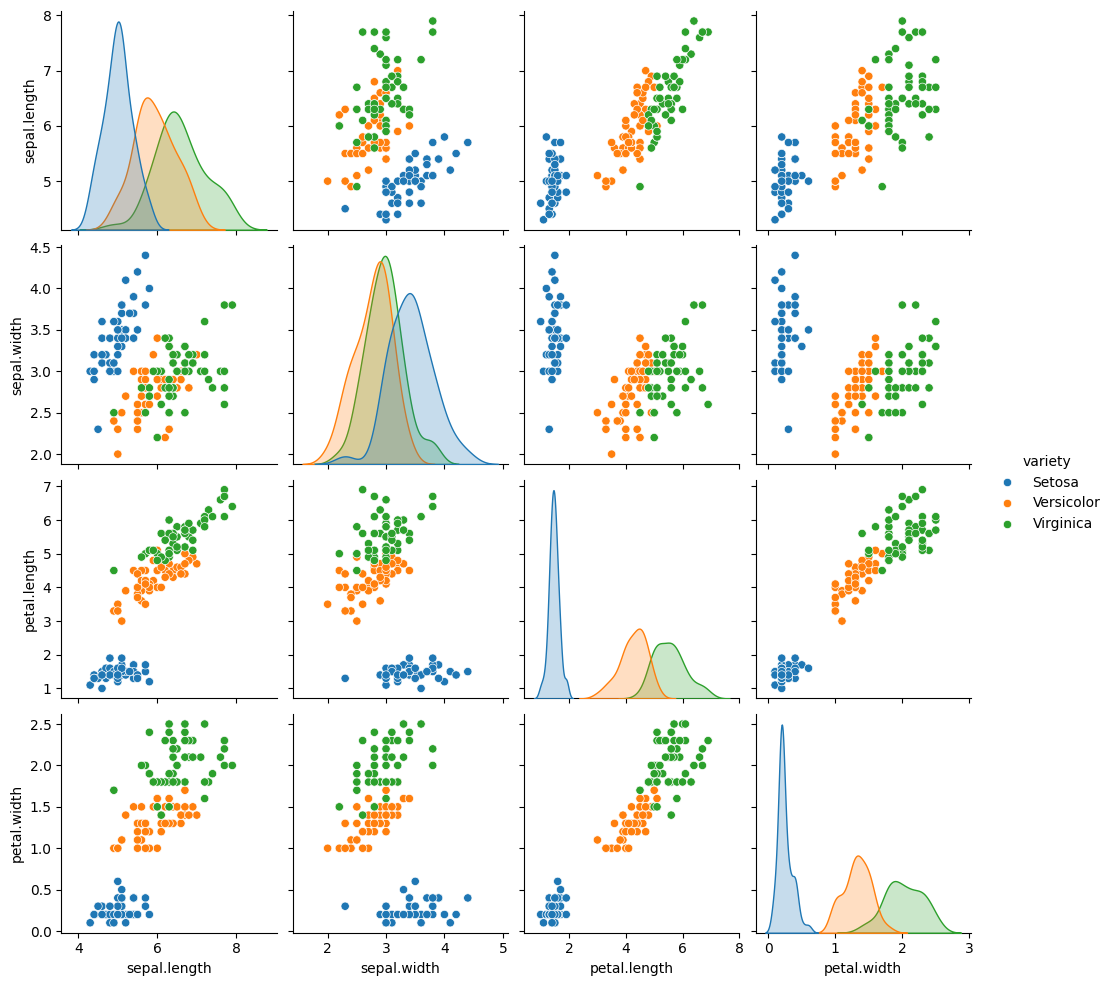

In [2]:
# Importation
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("dataset/iris.csv")

df_iris = data.copy()

# Description
print(df_iris.shape)
print(df_iris.ndim)
print(df_iris.size)
print(df_iris.columns)
print(df_iris.dtypes) 
print(df_iris.describe()) 

# distribution du sepale
plt.scatter(df_iris['sepal.length'], df_iris['sepal.width'])
plt.title("Distribution du sepale")
plt.show()

# distribution pair par pair
sns.pairplot(df_iris)
sns.pairplot(df_iris, hue="variety")


## 2 Parcelles de distribution avec Seaborn

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')
Index(['survived', 'pclass', 'sex', 'age', 'fare'], dtype='object')


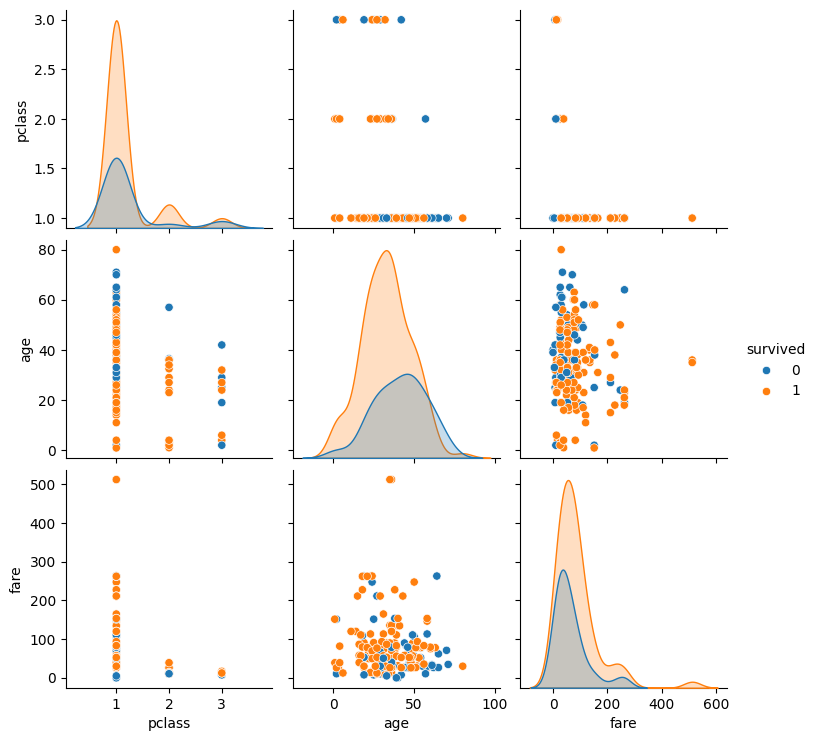

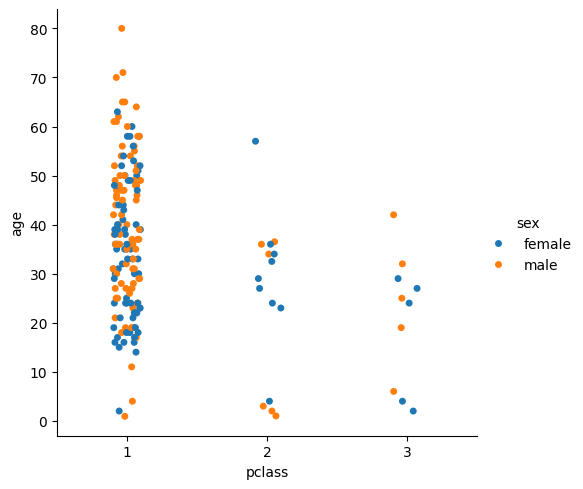

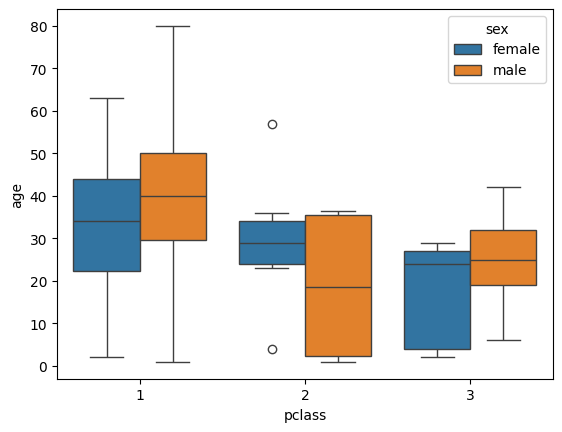

          survived    pclass       age      fare
survived  1.000000 -0.037698 -0.251045  0.130632
pclass   -0.037698  1.000000 -0.305708 -0.316796
age      -0.251045 -0.305708  1.000000 -0.090730
fare      0.130632 -0.316796 -0.090730  1.000000


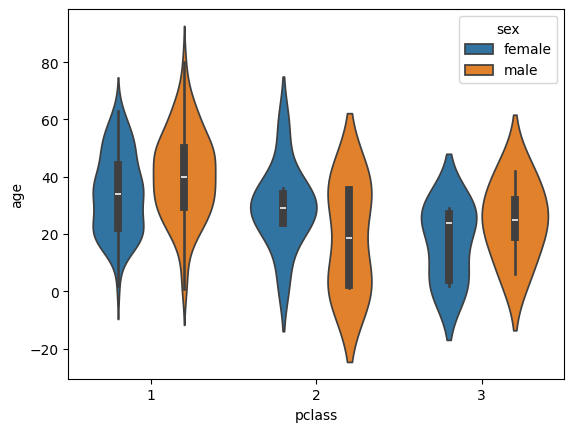

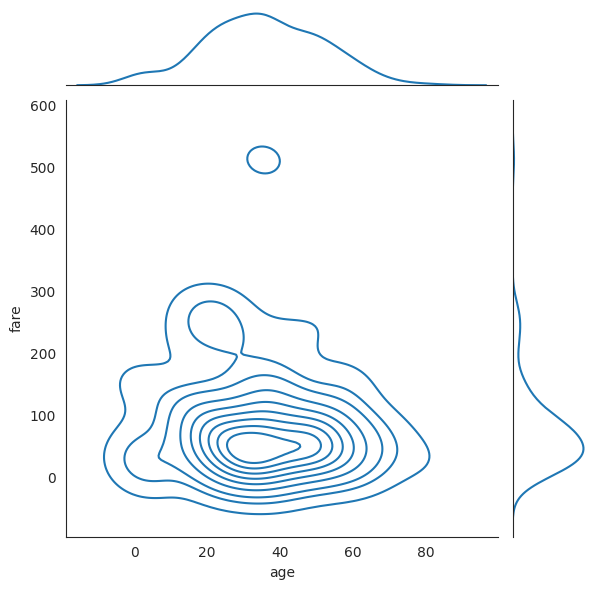

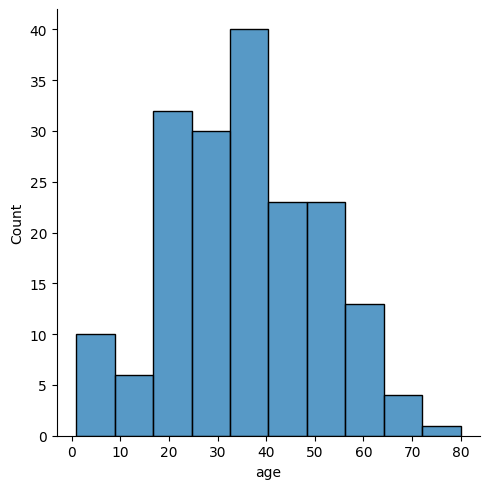

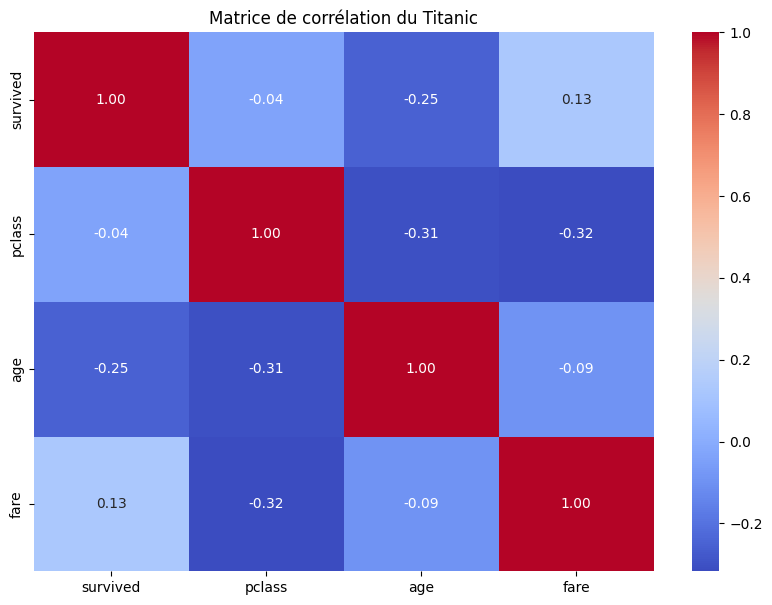

In [6]:
# On peut télécharger le dataset du titanic directement de Seaborn.
data = sns.load_dataset('titanic')

df_titanic = data.copy()

print(df_titanic.columns)

# Suppression des lignes null
df_titanic.dropna(inplace=True)
# Suppression des columns
df_titanic.drop(columns = ['sibsp', 'parch', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],inplace=True)

print(df_titanic.columns)

# Tracer les graphiques des distributions bivariées de titanic.
sns.pairplot(df_titanic, hue="survived")

# Graphiques pour des catégories
sns.catplot(x='pclass', y ='age', data=df_titanic, hue='sex')
plt.show()

# Boxplot de l'age en fonction de la classe selon le sex
sns.boxplot(data=df_titanic, x='pclass', y='age', hue="sex")
plt.show()

# Joue le même rôle que boxplot
sns.violinplot(x='pclass', y ='age', data=df_titanic, hue='sex')

# créer un jointplot avec une estimation de densité (KDE) entre l’âge et le tarif.
with sns.axes_style('white'):
    sns.jointplot(x='age', y ='fare', data=df_titanic, kind='kde')
    
# La fonction distplot() nous permet de réaliser les graphiques de distribution d’une variable quantitative. 
# Par défaut, elle réalise un histogramme avec une estimation de la densité. Tracer la distribution de la variable age.
sns.displot(data=df_titanic, x="age")

# Matrice de correlation 
matrice_corr = df_titanic.corr(numeric_only=True)

print(matrice_corr)

# Afficher la heatmap
plt.figure(figsize=(10, 7))

# Afficher la heatmap
sns.heatmap(matrice_corr,
            annot=True, # affiche la valeur de la correlation
            cmap="coolwarm", # coleur bleur/rouge
            fmt=".2f" # deux chiffres après la virgule
            )
plt.title("Matrice de corrélation du Titanic")
plt.show()